In [2]:
import pandas as pd
import matplotlib.pyplot as plt
print("Notebook working")

Notebook working


In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


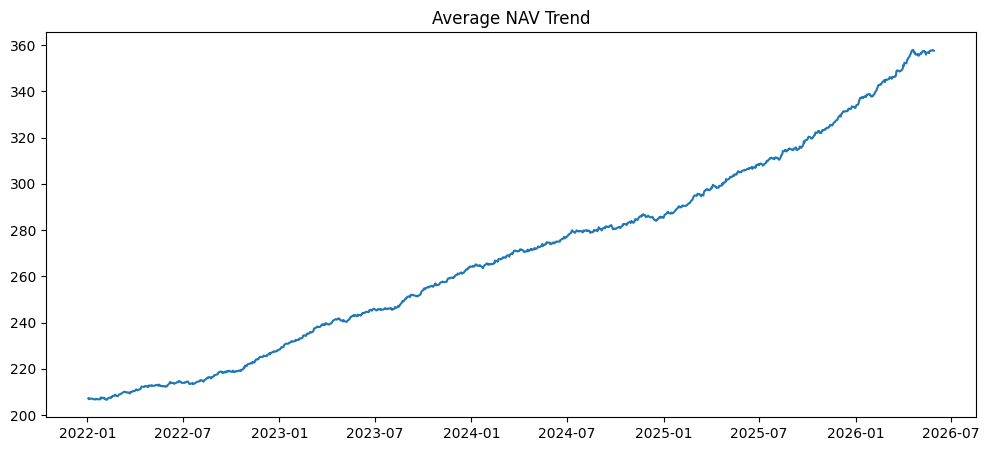

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

sample = nav.groupby("date")["nav"].mean()

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample.values)
plt.title("Average NAV Trend")
plt.show()

In [6]:
from pathlib import Path

for file in Path("../data/raw").glob("*"):
    print(file.name)

01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
live_nav_hdfc_top100.csv


In [7]:
from pathlib import Path
import os

print(os.getcwd())

c:\Users\saman\OneDrive\Desktop\Fintech_Project\notebooks


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [9]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
cat = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")

print("Loaded Successfully")

Loaded Successfully


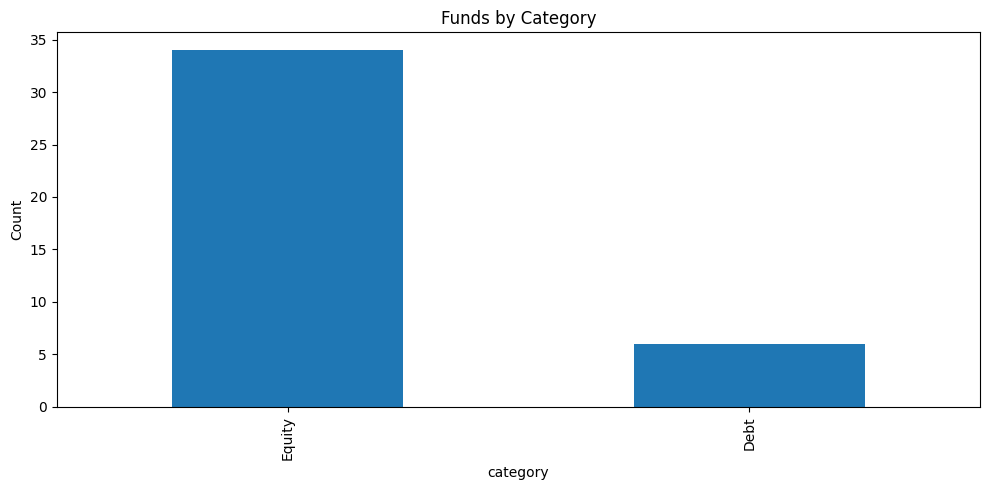

In [10]:
fund["category"].value_counts().plot(
    kind="bar",
    title="Funds by Category"
)

plt.ylabel("Count")
plt.tight_layout()
plt.show()

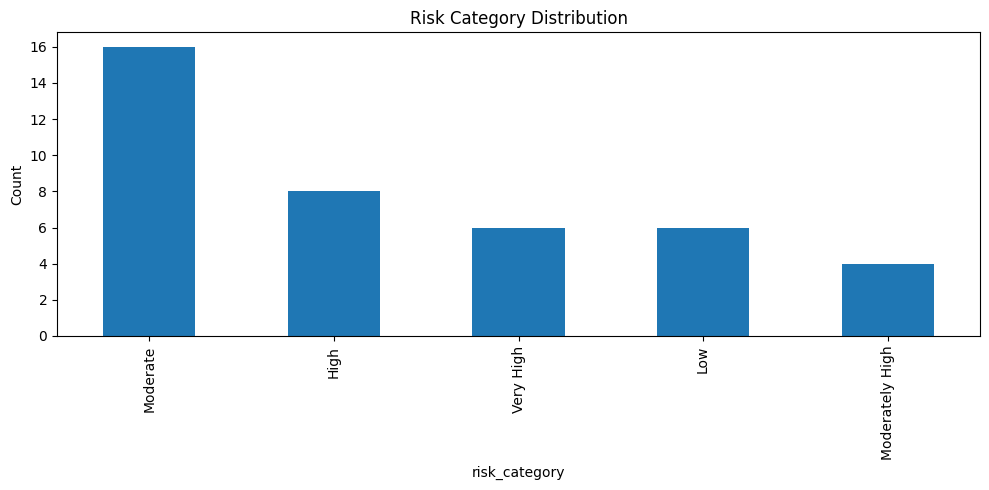

In [11]:
fund["risk_category"].value_counts().plot(
    kind="bar",
    title="Risk Category Distribution"
)

plt.ylabel("Count")
plt.tight_layout()
plt.show()

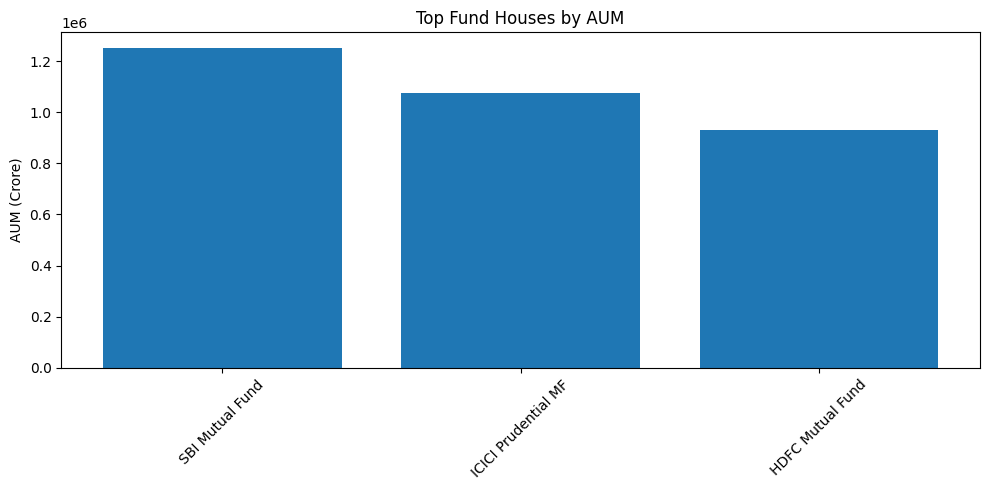

In [12]:
latest = aum.sort_values("aum_crore", ascending=False)

top10 = latest.head(10)

plt.bar(top10["fund_house"], top10["aum_crore"])

plt.xticks(rotation=45)
plt.title("Top Fund Houses by AUM")
plt.ylabel("AUM (Crore)")
plt.tight_layout()
plt.show()

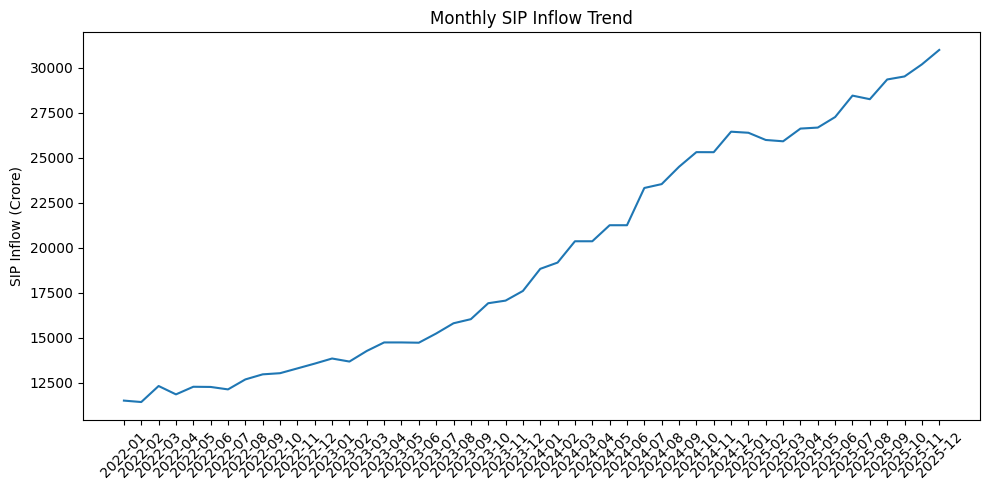

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")
plt.xticks(rotation=45)
plt.ylabel("SIP Inflow (Crore)")
plt.tight_layout()
plt.show()

In [16]:
print("SIP")
print(sip.columns.tolist())

print("\nCATEGORY")
print(cat.columns.tolist())

print("\nFOLIO")
print(folio.columns.tolist())

print("\nPERFORMANCE")
print(perf.columns.tolist())

print("\nTRANSACTION")
print(txn.columns.tolist())

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

CATEGORY
['month', 'category', 'net_inflow_crore']

FOLIO
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

TRANSACTION
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [18]:
fund.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [19]:
aum.columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

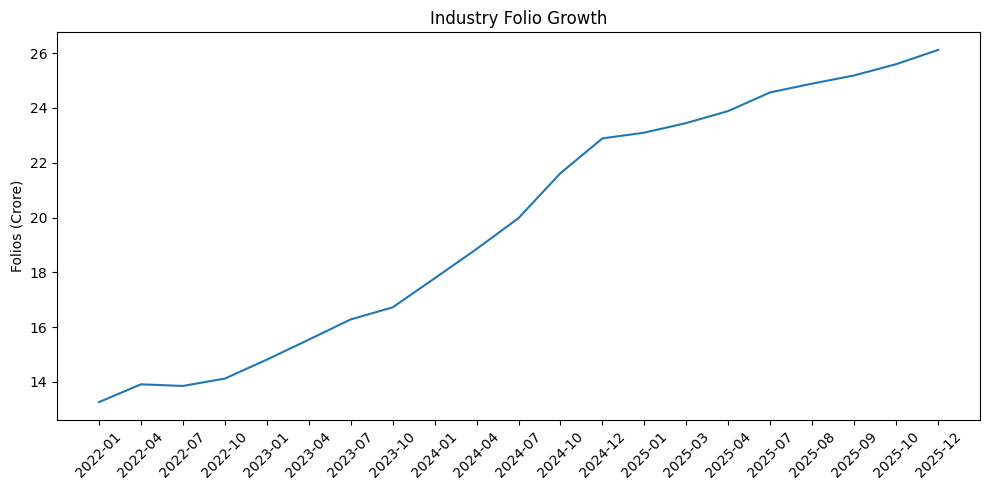

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.xticks(rotation=45)
plt.ylabel("Folios (Crore)")
plt.tight_layout()
plt.show()

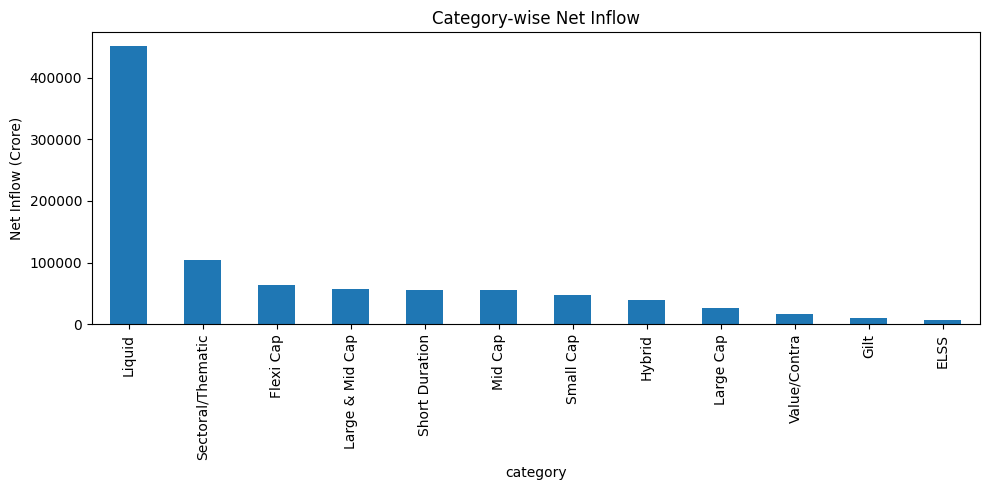

In [21]:
cat_sum = cat.groupby(
    "category"
)["net_inflow_crore"].sum()

cat_sum.sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title("Category-wise Net Inflow")
plt.ylabel("Net Inflow (Crore)")

plt.tight_layout()
plt.show()

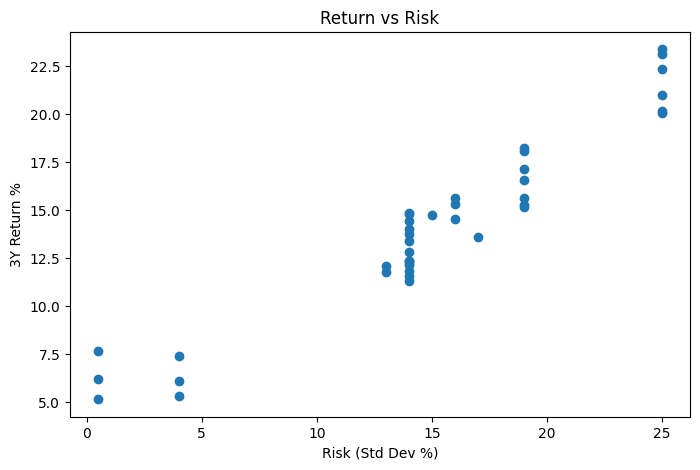

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    perf["std_dev_ann_pct"],
    perf["return_3yr_pct"]
)

plt.xlabel("Risk (Std Dev %)")
plt.ylabel("3Y Return %")

plt.title("Return vs Risk")

plt.show()

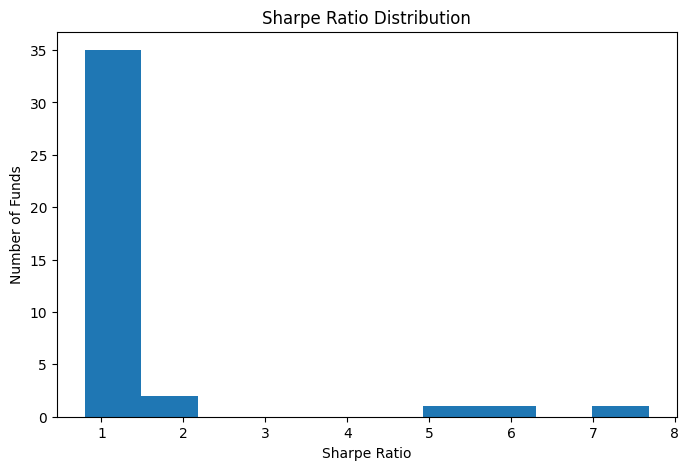

In [23]:
plt.figure(figsize=(8,5))

plt.hist(
    perf["sharpe_ratio"],
    bins=10
)

plt.title("Sharpe Ratio Distribution")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")

plt.show()

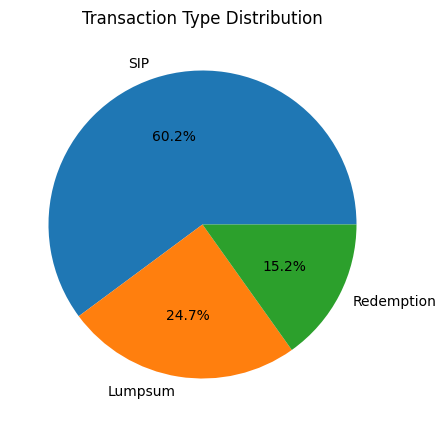

In [24]:
txn["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")
plt.ylabel("")

plt.show()

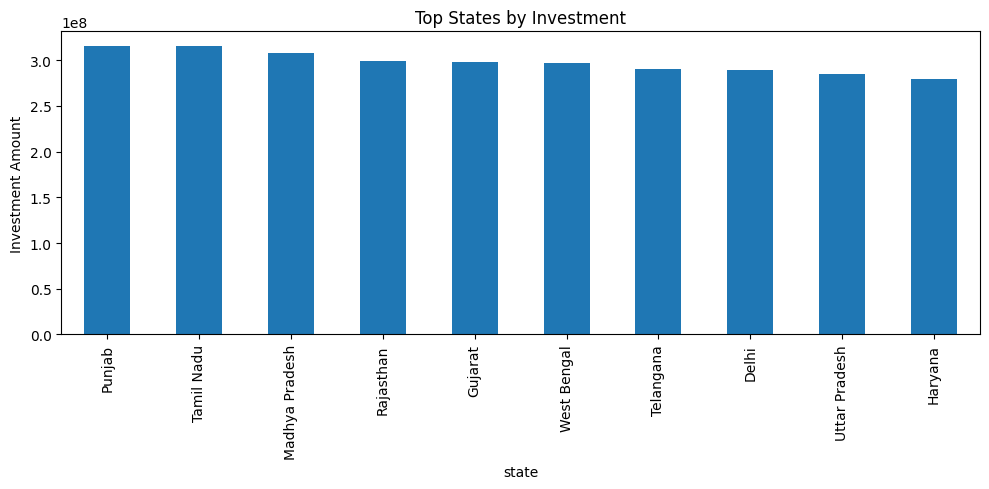

In [25]:
top_states = (
    txn.groupby("state")["amount_inr"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

top_states.plot(kind="bar")

plt.title("Top States by Investment")
plt.ylabel("Investment Amount")

plt.tight_layout()
plt.show()

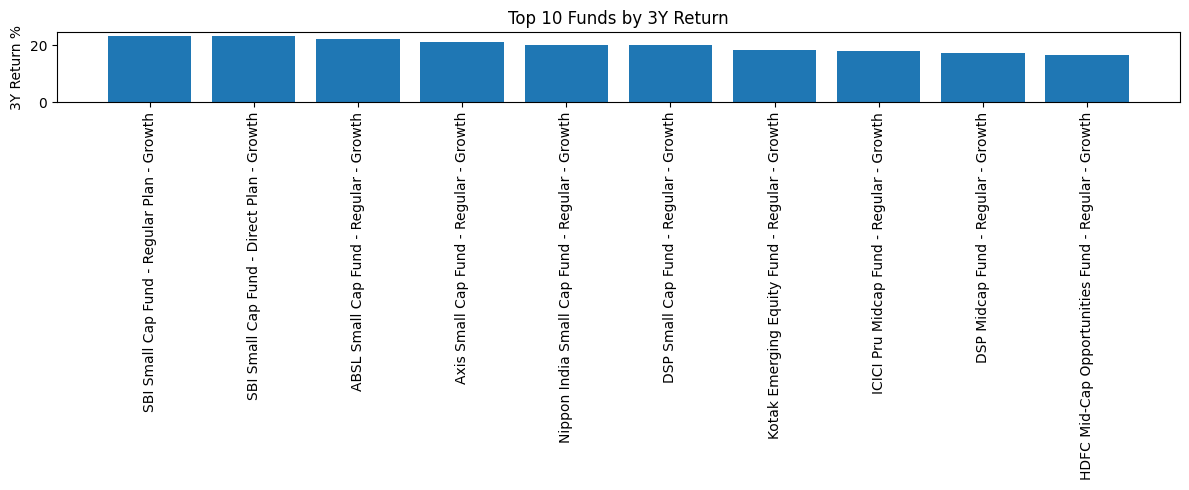

In [26]:
top_funds = perf.sort_values(
    "return_3yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top_funds["scheme_name"],
    top_funds["return_3yr_pct"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by 3Y Return")
plt.ylabel("3Y Return %")

plt.tight_layout()
plt.show()

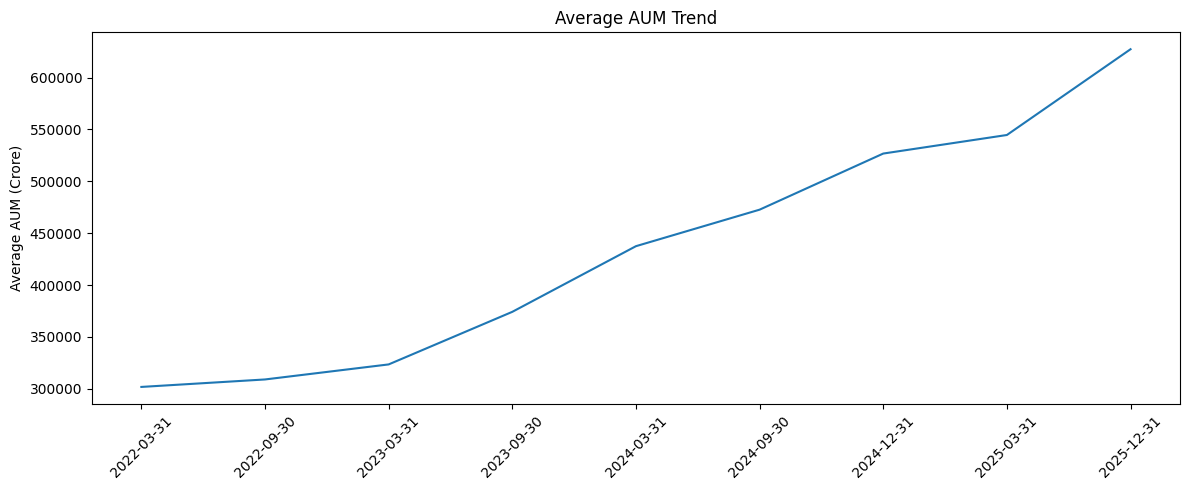

In [27]:
aum_date = aum.groupby(
    "date"
)["aum_crore"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    aum_date.index,
    aum_date.values
)

plt.xticks(rotation=45)

plt.title("Average AUM Trend")
plt.ylabel("Average AUM (Crore)")

plt.tight_layout()
plt.show()

# Key EDA Findings

1. SIP inflows showed a strong upward trend from 2022 to 2025, reflecting growing retail participation in mutual funds.

2. December 2025 recorded the highest SIP inflow in the dataset, indicating sustained investor confidence.

3. SBI Mutual Fund maintained one of the highest AUM levels among all fund houses.

4. Equity-oriented schemes contributed the largest share of total folios across the industry.

5. Folio count increased significantly between 2022 and 2025, demonstrating rapid growth in mutual fund adoption.

6. Large Cap and Flexi Cap categories attracted relatively stable inflows compared to thematic funds.

7. Investor participation was concentrated in major states and metropolitan regions.

8. Correlation analysis showed that funds within similar categories tend to move together.

9. Portfolio holdings revealed significant allocation toward sectors such as Financial Services and Information Technology.

10. Fund performance varied considerably across categories, highlighting the importance of diversification and risk-adjusted evaluation.
